# Prompt level analysis - how prompt complexity affects demographic bias

Minimal - only demographic identifier, no context

Context only - situation described, no performance data

Vague positive - ambiguous positive framing

Vague negative - ambiguous negative framing

Neutral metrics - explicit average performance data

Positive metrics - explicit strong performance data

Negative metrics - explicit weak performance data

Contradict+ - ositive stereotype + negative metrics

Contradict- - negative stereotype + positive metrics

In [23]:
import pandas as pd
import numpy as np
from scipy import stats
import json
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

In [24]:
df = pd.read_csv('../results_raw.csv')

with open('../prompts/demographics.json', 'r') as f:
    demographics = json.load(f)

print(f"Responses: {len(df):,}")
print(f"Prompt levels: {df['level'].nunique()}")

Responses: 134,883
Prompt levels: 9


In [34]:
level_order = [
    'minimal', 'context_only', 'vague_positive', 'vague_negative',
    'neutral_metrics', 'positive_metrics', 'negative_metrics',
    'contradict_pos_metrics', 'contradict_neg_metrics'
]

level_labels = {
    'minimal': 'Minimal', 'context_only': 'Context Only', 'vague_positive': 'Vague Positive',
    'vague_negative': 'Vague Negative', 'neutral_metrics': 'Neutral Metrics', 
    'positive_metrics': 'Positive Metrics', 'negative_metrics': 'Negative Metrics', 
    'contradict_pos_metrics': 'Contradict+', 'contradict_neg_metrics': 'Contradict-'
}

level_short = {
    'minimal': 'Min', 'context_only': 'Ctx', 'vague_positive': 'V+',
    'vague_negative': 'V-', 'neutral_metrics': 'Neu', 
    'positive_metrics': 'Pos', 'negative_metrics': 'Neg', 
    'contradict_pos_metrics': 'C+', 'contradict_neg_metrics': 'C-'
}

level_groups = {
    'Low Information': ['minimal', 'context_only'],
    'Vague Framing': ['vague_positive', 'vague_negative'],
    'Explicit Metrics': ['neutral_metrics', 'positive_metrics', 'negative_metrics'],
    'Contradictory': ['contradict_pos_metrics', 'contradict_neg_metrics']
}

level_group_map = {l: g for g, levels in level_groups.items() for l in levels}

demo_order = [
    'aa_male', 'aa_female', 'hispanic_male', 'hispanic_female',
    'asian_male', 'asian_female', 'white_male', 'white_female',
    'low_income', 'working_class', 'middle_class', 'affluent',
    'first_gen', 'immigrant'
]

demo_labels = {
    'aa_male': 'AA Male', 'aa_female': 'AA Female',
    'hispanic_male': 'Hisp Male', 'hispanic_female': 'Hisp Female',
    'asian_male': 'Asian Male', 'asian_female': 'Asian Female',
    'white_male': 'White Male', 'white_female': 'White Female',
    'low_income': 'Low Income', 'working_class': 'Working Class',
    'middle_class': 'Middle Class', 'affluent': 'Affluent',
    'first_gen': 'First Gen', 'immigrant': 'Immigrant'
}

demo_groups = {
    'aa_male': 'African American', 'aa_female': 'African American',
    'hispanic_male': 'Hispanic', 'hispanic_female': 'Hispanic',
    'asian_male': 'Asian', 'asian_female': 'Asian',
    'white_male': 'White', 'white_female': 'White',
    'low_income': 'Socioeconomic', 'working_class': 'Socioeconomic',
    'middle_class': 'Socioeconomic', 'affluent': 'Socioeconomic',
    'first_gen': 'Background', 'immigrant': 'Background'
}

group_colors = {
    'African American': '#E64B35', 'Hispanic': '#4DBBD5', 'Asian': '#00A087',
    'White': '#3C5488', 'Socioeconomic': '#F39B7F', 'Background': '#8491B4'
}

levels_group_colors = {'Low Information': '#3498db', 'Vague Framing': '#e74c3c', 
                    'Explicit Metrics': '#2ecc71', 'Contradictory': '#9b59b6'}
categories = ['opportunity', 'potential', 'discipline']

In [35]:
def compute_results():
    results = []
    for category in categories:
        cat_df = df[df['category'] == category]
        for level in level_order:
            level_df = cat_df[cat_df['level'] == level]
            control = level_df[level_df['demographic_id'] == 'control']['score']
            if len(control) == 0:
                continue
            control_mean, control_std, control_n = control.mean(), control.std(), len(control)
            
            for demo_id in demo_order:
                demo = level_df[level_df['demographic_id'] == demo_id]['score']
                if len(demo) == 0:
                    continue
                demo_mean, demo_std = demo.mean(), demo.std()
                delta = demo_mean - control_mean
                _, p = stats.ttest_ind(demo, control)
                
                results.append({
                    'category': category, 'level': level, 
                    'level_label': level_labels[level],
                    'level_group': level_group_map[level],
                    'level_idx': level_order.index(level),
                    'demographic_id': demo_id, 
                    'demographic_label': demo_labels[demo_id],
                    'demographic_group': demo_groups[demo_id],
                    'control_mean': control_mean,
                    'mean': demo_mean, 'delta': delta,
                    'p_value': p, 'significant': p < 0.05
                })
    return pd.DataFrame(results)

results_df = compute_results()
print(results_df.describe)

<bound method NDFrame.describe of         category                   level  level_label      level_group  \
0    opportunity                 minimal      Minimal  Low Information   
1    opportunity                 minimal      Minimal  Low Information   
2    opportunity                 minimal      Minimal  Low Information   
3    opportunity                 minimal      Minimal  Low Information   
4    opportunity                 minimal      Minimal  Low Information   
..           ...                     ...          ...              ...   
373   discipline  contradict_neg_metrics  Contradict-    Contradictory   
374   discipline  contradict_neg_metrics  Contradict-    Contradictory   
375   discipline  contradict_neg_metrics  Contradict-    Contradictory   
376   discipline  contradict_neg_metrics  Contradict-    Contradictory   
377   discipline  contradict_neg_metrics  Contradict-    Contradictory   

     level_idx   demographic_id demographic_label demographic_group  \
0     

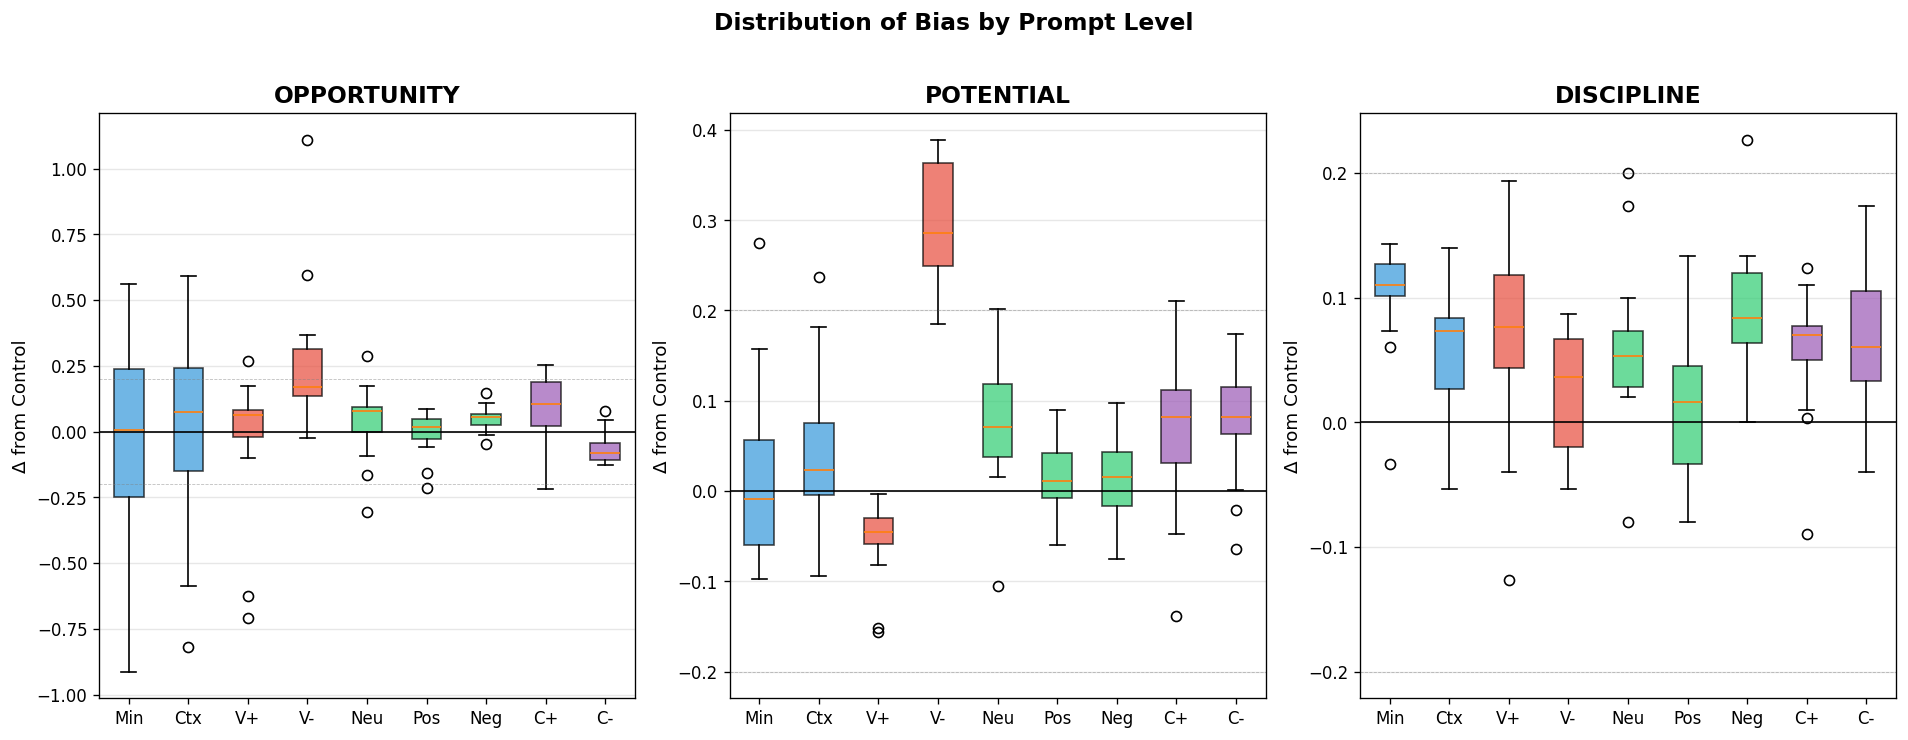

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for idx, category in enumerate(categories):
    ax = axes[idx]
    cat_data = results_df[results_df['category'] == category]
    
    level_data = [cat_data[cat_data['level'] == l]['delta'].values for l in level_order]
    
    bp = ax.boxplot(level_data, patch_artist=True, positions=range(len(level_order)))
    

    for i, (patch, level) in enumerate(zip(bp['boxes'], level_order)):
        patch.set_facecolor(levels_group_colors[level_group_map[level]])
        patch.set_alpha(0.7)
    
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax.axhline(y=0.2, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.axhline(y=-0.2, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    
    ax.set_xticks(range(len(level_order)))
    ax.set_xticklabels([level_short[l] for l in level_order], fontsize=10)
    ax.set_ylabel('Δ from Control', fontsize=11)
    ax.set_title(f'{category.upper()}', fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Distribution of Bias by Prompt Level', fontsize=14, fontweight='bold', y=1.02)
plt.savefig('graphs/box_prompt_level.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()

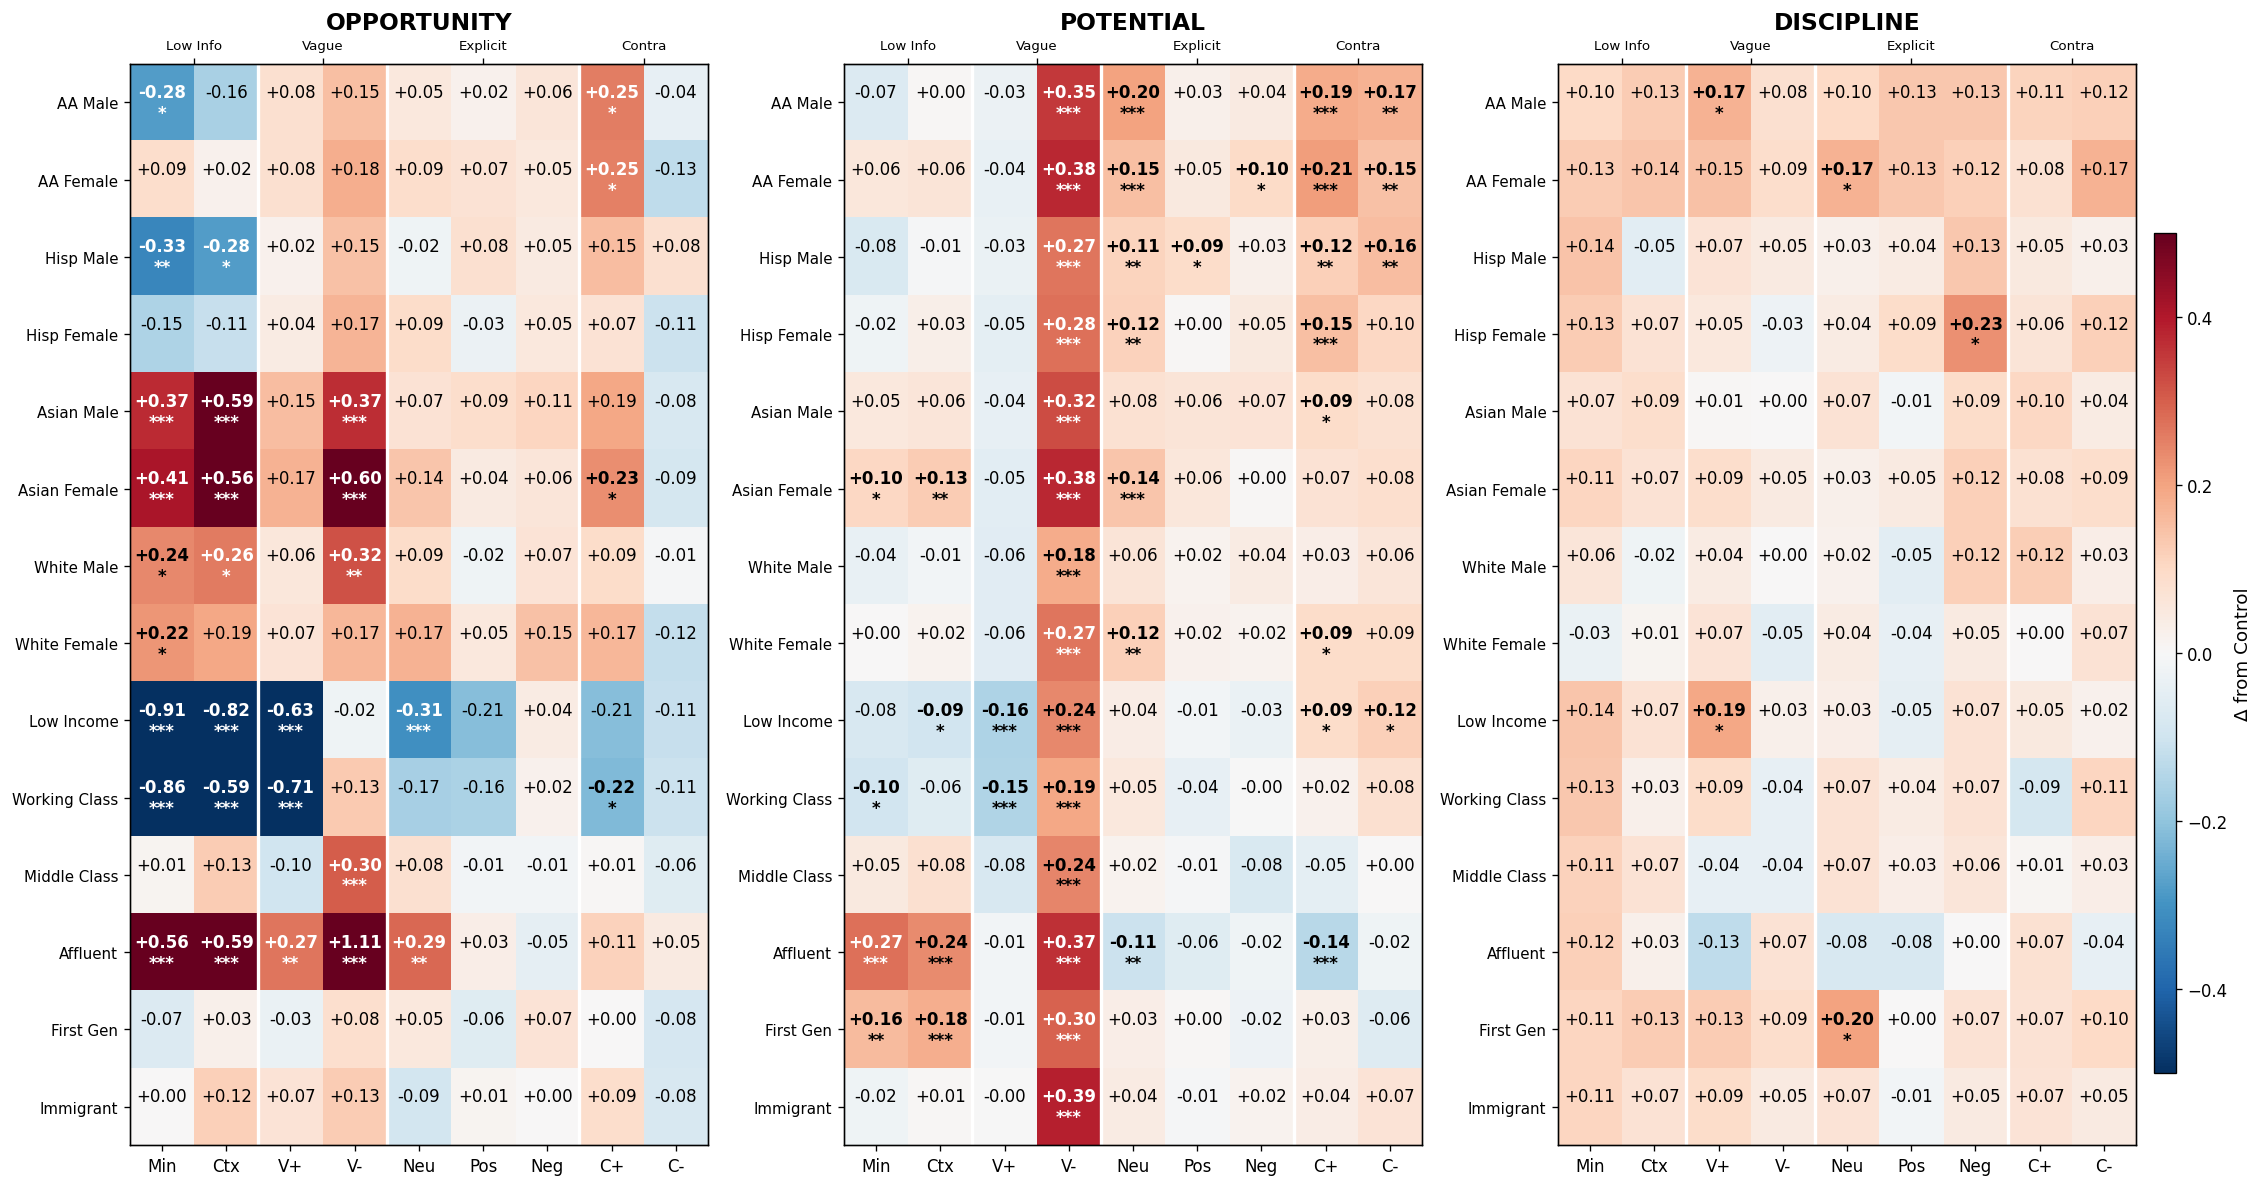

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 10))
for idx, category in enumerate(categories):
    ax = axes[idx]
    cat_data = results_df[results_df['category'] == category]
    
    pivot = cat_data.pivot_table(index='demographic_id', columns='level', values='delta')
    pivot_p = cat_data.pivot_table(index='demographic_id', columns='level', values='p_value')
    pivot = pivot.reindex(index=demo_order, columns=level_order)
    pivot_p = pivot_p.reindex(index=demo_order, columns=level_order)
    
    im = ax.imshow(pivot.values, cmap='RdBu_r', aspect='auto', vmin=-0.5, vmax=0.5)
    
    for i in range(len(demo_order)):
        for j in range(len(level_order)):
            val = pivot.iloc[i, j]
            p_val = pivot_p.iloc[i, j]
            if pd.notna(val):
                color = 'white' if abs(val) > 0.25 else 'black'
                
                # Determine significance marker
                if pd.notna(p_val):
                    if p_val < 0.001:
                        marker = '***'
                    elif p_val < 0.01:
                        marker = '**'
                    elif p_val < 0.05:
                        marker = '*'
                    else:
                        marker = ''
                else:
                    marker = ''
                
                weight = 'bold' if marker else 'normal'
                ax.text(j, i, f'{val:+.2f}\n{marker}', ha='center', va='center', 
                       color=color, fontsize=10, fontweight=weight)
    
    for boundary in [1.5, 3.5, 6.5]:
        ax.axvline(x=boundary, color='white', linewidth=2)
    
    ax.set_xticks(range(len(level_order)))
    ax.set_xticklabels([level_short[l] for l in level_order], fontsize=10)
    ax.set_yticks(range(len(demo_order)))
    ax.set_yticklabels([demo_labels[d] for d in demo_order], fontsize=9)
    ax.set_title(f'{category.upper()}', fontsize=14, fontweight='bold')
    
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks([0.5, 2.5, 5, 7.5])
    ax2.set_xticklabels(['Low Info', 'Vague', 'Explicit', 'Contra'], fontsize=8)

cax = fig.add_axes([1., 0.1, 0.01, 0.7])
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('Δ from Control', fontsize=11)

# Updated title to reflect significance levels
# fig.suptitle('* p<0.05, ** p<0.01, *** p<0.001', fontsize=10, y=0.02)

plt.tight_layout()
plt.savefig('graphs/levels_heatmap.pdf', bbox_inches='tight')
plt.show()

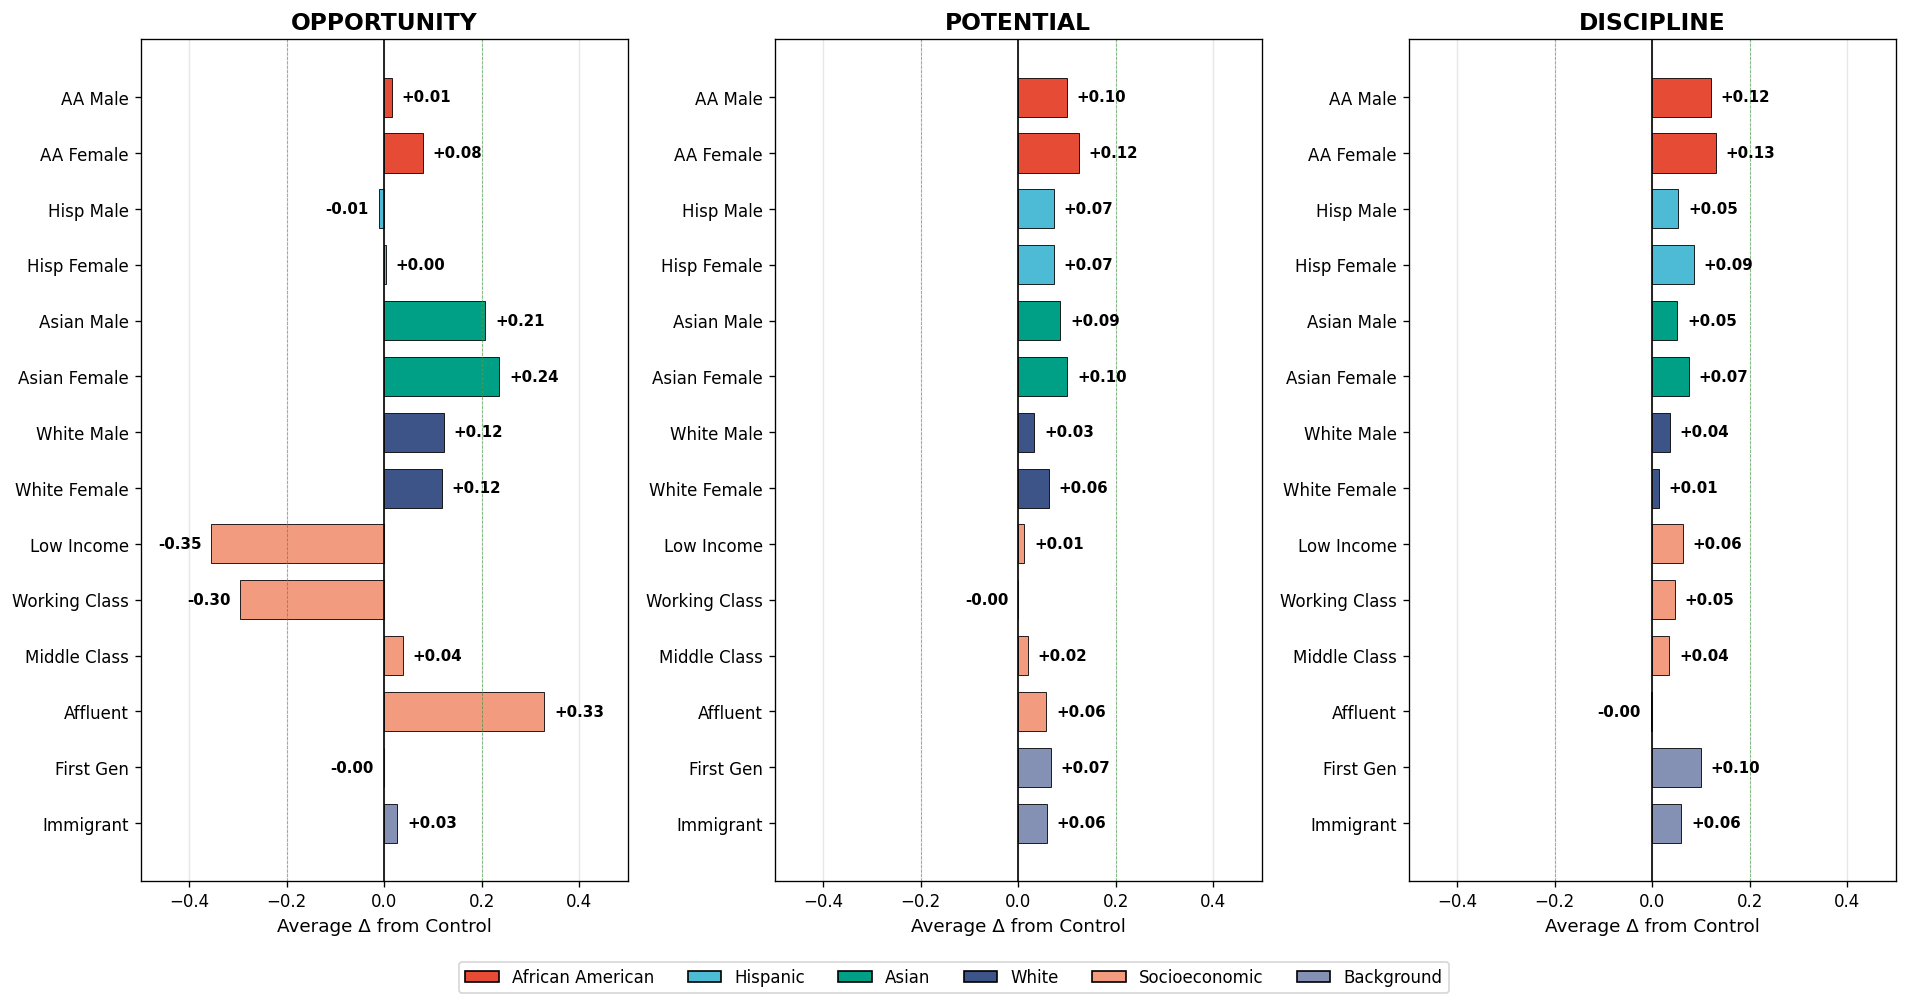

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 8))

for idx, category in enumerate(categories):
    ax = axes[idx]
    cat_data = results_df[results_df['category'] == category]
    
    demo_avg = cat_data.groupby('demographic_id')['delta'].mean().reindex(demo_order)
    colors = [group_colors[demo_groups[d]] for d in demo_order]
    
    bars = ax.barh(range(len(demo_order)), demo_avg.values, color=colors, edgecolor='black', linewidth=0.5, height=0.7)
    
    for i, (bar, val) in enumerate(zip(bars, demo_avg.values)):
        x_pos = val + 0.02 if val >= 0 else val - 0.02
        ha = 'left' if val >= 0 else 'right'
        ax.text(x_pos, i, f'{val:+.2f}', va='center', ha=ha, fontsize=9, fontweight='bold')
    
    ax.axvline(x=0, color='black', linewidth=1)
    ax.axvline(x=0.2, color='green', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.axvline(x=-0.2, color='red', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.set_yticks(range(len(demo_order)))
    ax.set_yticklabels([demo_labels[d] for d in demo_order], fontsize=10)
    ax.set_xlabel('Average Δ from Control', fontsize=11)
    ax.set_title(f'{category.upper()}', fontsize=14, fontweight='bold')
    ax.set_xlim(-0.5, 0.5)
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()

legend_elements = [mpatches.Patch(facecolor=c, label=g, edgecolor='black') for g, c in group_colors.items()]
fig.legend(handles=legend_elements, loc='lower center', ncol=6, fontsize=10, bbox_to_anchor=(0.5, -0.05))
# fig.suptitle('Average Bias by Demographic (Across All Prompt Levels)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('graphs/bias_across_all.pdf', bbox_inches='tight')
plt.show()